# Stage 5 — 1D-CNN Classifier (Primary Model)
### Cancer Prediction from Gene Expression Data — Prediction Track
### Binary Classification: Tumor (1) vs Normal (0)

This notebook loads the 64-dim Autoencoder fingerprints from `03_autoencoder.ipynb` and trains the primary
1D-CNN classifier.

**Architecture:**

| Layer | Config |
|---|---|
| Input | 64-dim fingerprint, reshaped to (64, 1) |
| Conv1D Layer 1 | 32 filters, kernel size 3, ReLU |
| MaxPooling1D | pool size 2 |
| Conv1D Layer 2 | 64 filters, kernel size 3, ReLU |
| MaxPooling1D | pool size 2 |
| Flatten | — |
| Dense | 128, ReLU |
| Dropout | 0.3 |
| Output | 1 neuron, Sigmoid (binary: tumor probability) |

Loss: Binary Cross-Entropy. Optimizer: Adam, lr=0.001. Evaluated with 5-fold cross-validation on the
training set, then a final model trained on the full training set and evaluated on the held-out test set.

## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Gene Project/processed_data"
MODEL_DIR = "/content/drive/MyDrive/Gene Project/models"
RESULTS_DIR = "/content/drive/MyDrive/Gene Project/results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("GPU available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
GPU available: []


## 1. Load Autoencoder-Encoded Data

In [4]:
X_train = pd.read_csv(f"{DATA_DIR}/X_train_encoded.csv").values
X_test = pd.read_csv(f"{DATA_DIR}/X_test_encoded.csv").values
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").iloc[:, 0].values
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").iloc[:, 0].values
label_mapping = joblib.load(f"{DATA_DIR}/label_mapping.pkl")

# Reshape for Conv1D: (samples, timesteps, channels) = (samples, 64, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train_cnn:", X_train_cnn.shape, " X_test_cnn:", X_test_cnn.shape)
print("Label mapping:", label_mapping)
print("Train class balance:", pd.Series(y_train).value_counts().to_dict())

X_train_cnn: (860, 64, 1)  X_test_cnn: (117, 64, 1)
Label mapping: {0: 'normal', 1: 'tumor'}
Train class balance: {1: 430, 0: 430}


## 2. Build the 1D-CNN Model

In [5]:
def build_cnn(input_length):
    model = keras.Sequential([
        keras.Input(shape=(input_length, 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Preview the architecture
build_cnn(X_train_cnn.shape[1]).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 64, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 32, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,665 (537.75 KB)

 Trainable params: 137,665 (537.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3. 5-Fold Cross-Validation
Evaluates how consistently the model performs across different train/validation splits of the training
data, before committing to a single final model. This matters more than usual here because of the small
sample size — a single train/val split could get lucky or unlucky.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_accuracies, fold_f1s, fold_aucs = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_cnn, y_train), start=1):
    X_fold_train, X_fold_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    model = build_cnn(X_train_cnn.shape[1])

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=100,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    val_probs = model.predict(X_fold_val, verbose=0).ravel()
    val_preds = (val_probs >= 0.5).astype(int)

    acc = accuracy_score(y_fold_val, val_preds)
    f1 = f1_score(y_fold_val, val_preds)
    auc = roc_auc_score(y_fold_val, val_probs)

    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    fold_aucs.append(auc)

    print(f"Fold {fold}: Accuracy={acc:.4f}  F1={f1:.4f}  ROC-AUC={auc:.4f}")

print("\n--- 5-Fold Cross-Validation Summary ---")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Mean F1-Score: {np.mean(fold_f1s):.4f} (+/- {np.std(fold_f1s):.4f})")
print(f"Mean ROC-AUC:  {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

Fold 1: Accuracy=0.9709  F1=0.9714  ROC-AUC=0.9970
Fold 2: Accuracy=0.9709  F1=0.9718  ROC-AUC=0.9959


Fold 3: Accuracy=0.9709  F1=0.9714  ROC-AUC=0.9959


Fold 4: Accuracy=0.9884  F1=0.9885  ROC-AUC=0.9982
Fold 5: Accuracy=0.9826  F1=0.9829  ROC-AUC=0.9992

--- 5-Fold Cross-Validation Summary ---
Mean Accuracy: 0.9767 (+/- 0.0074)
Mean F1-Score: 0.9772 (+/- 0.0072)
Mean ROC-AUC:  0.9973 (+/- 0.0013)


## 4. Train the Final Model
Using the full training set (all folds combined), with a small validation split just to monitor and
early-stop training — the real, unbiased evaluation happens on the held-out test set in the next step.

In [7]:
final_model = build_cnn(X_train_cnn.shape[1])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = final_model.fit(
    X_train_cnn, y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8509 - loss: 0.3208 - val_accuracy: 0.8140 - val_loss: 0.4027
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9097 - loss: 0.2036 - val_accuracy: 0.8837 - val_loss: 0.2954
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9316 - loss: 0.1588 - val_accuracy: 0.8915 - val_loss: 0.3168
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9384 - loss: 0.1349 - val_accuracy: 0.9302 - val_loss: 0.1576
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9562 - loss: 0.1036 - val_accuracy: 0.9457 - val_loss: 0.1431
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9603 - loss: 0.0900 - val_accuracy: 0.9845 - val_loss: 0.0636
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9644 - loss: 0.0850 - val_accuracy: 0.9845 - val_loss: 0.0495
Epoch 8/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9672 - loss: 0.0769 - val_accuracy: 0.9845 - 

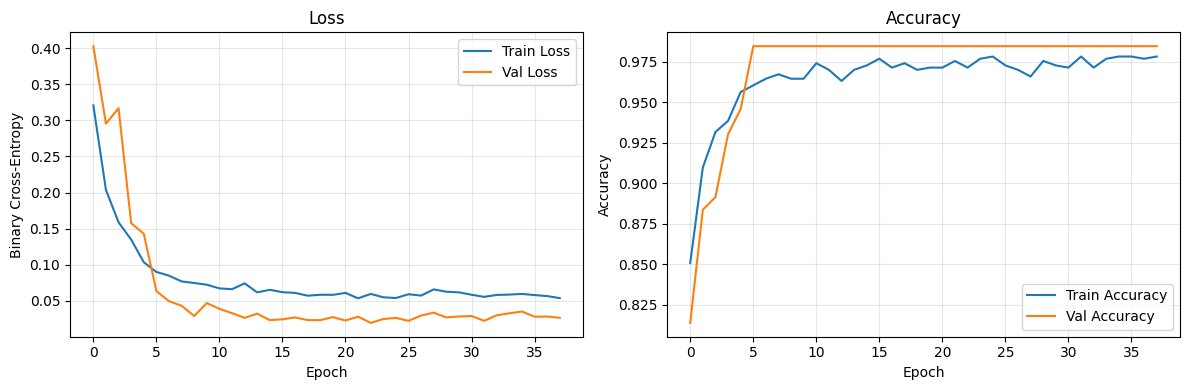

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Accuracy")

plt.tight_layout()
plt.show()

## 5. Evaluate on the Held-Out Test Set
This is the real, unbiased performance estimate — the test set was never used in training, validation
splits, or cross-validation above.

In [9]:
test_probs = final_model.predict(X_test_cnn, verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)

accuracy = accuracy_score(y_test, test_preds)
precision = precision_score(y_test, test_preds)
recall = recall_score(y_test, test_preds)   # sensitivity — most critical metric for cancer detection
f1 = f1_score(y_test, test_preds)
roc_auc = roc_auc_score(y_test, test_probs)

print("=== 1D-CNN Test Set Performance ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}   <-- most important metric here")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

cnn_metrics = {
    "accuracy": accuracy, "precision": precision, "recall": recall,
    "f1": f1, "roc_auc": roc_auc
}
joblib.dump(cnn_metrics, f"{RESULTS_DIR}/cnn_test_metrics.pkl")

=== 1D-CNN Test Set Performance ===
Accuracy:  0.9744
Precision: 0.9907
Recall (Sensitivity): 0.9817   <-- most important metric here
F1-Score:  0.9862
ROC-AUC:   0.9920


['/content/drive/MyDrive/Gene Project/results/cnn_test_metrics.pkl']

## 6. Confusion Matrix

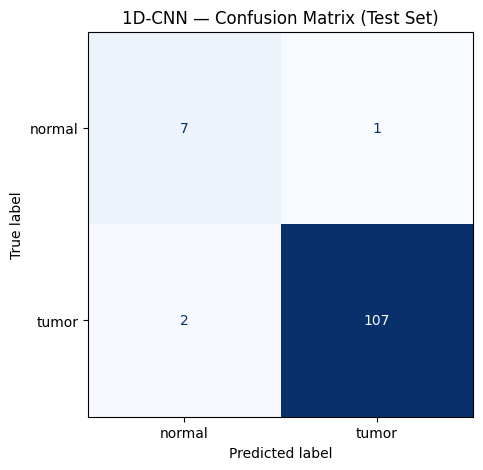

True Negatives (correctly identified normal): 7
False Positives (normal misclassified as tumor): 1
False Negatives (tumor MISSED — most dangerous error): 2
True Positives (correctly identified tumor): 107


In [10]:
cm = confusion_matrix(y_test, test_preds)
label_names = [label_mapping[0], label_mapping[1]]  # ["normal", "tumor"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("1D-CNN — Confusion Matrix (Test Set)")
plt.savefig(f"{RESULTS_DIR}/cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly identified normal): {tn}")
print(f"False Positives (normal misclassified as tumor): {fp}")
print(f"False Negatives (tumor MISSED — most dangerous error): {fn}")
print(f"True Positives (correctly identified tumor): {tp}")

## 7. ROC Curve

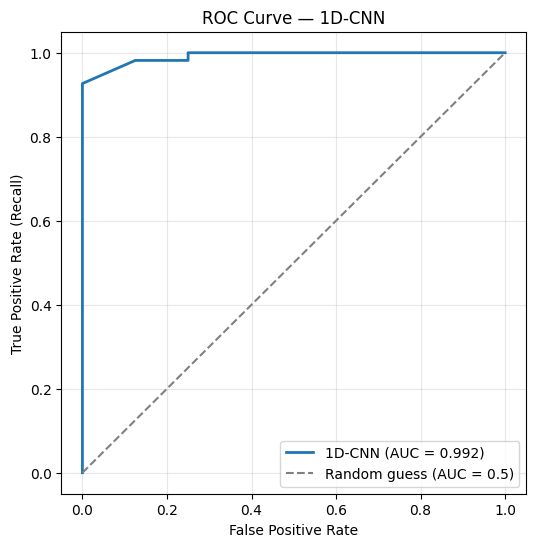

In [11]:
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"1D-CNN (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — 1D-CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/cnn_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save the Trained Model

In [12]:
final_model.save(f"{MODEL_DIR}/cnn_model.h5")

print("Saved CNN model to:", f"{MODEL_DIR}/cnn_model.h5")
print("Saved metrics and plots to:", RESULTS_DIR)
print(os.listdir(MODEL_DIR))
print(os.listdir(RESULTS_DIR))

Saved CNN model to: /content/drive/MyDrive/Gene Project/models/cnn_model.h5
Saved metrics and plots to: /content/drive/MyDrive/Gene Project/results
['encoder_model.h5', 'autoencoder_full.h5', 'cnn_model.h5']
['cnn_test_metrics.pkl', 'cnn_confusion_matrix.png', 'cnn_roc_curve.png']


In [13]:
!du -sh "/content/drive/MyDrive/Gene Project/models/"*

2.8M	/content/drive/MyDrive/Gene Project/models/autoencoder_full.h5
1.7M	/content/drive/MyDrive/Gene Project/models/cnn_model.h5
479K	/content/drive/MyDrive/Gene Project/models/encoder_model.h5


In [ ]:
# Configure your Git identity
!git config --global user.name "meenakshideepkumar-ui"
!git config --global user.email "meenakshideepkumar@gmail.com.com"

# Clone the repository into a local folder named 'repo'
!git clone https://github.com/meenakshideepkumar-ui/Cancer-gene-expression-ai.git /content/repo